In [53]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

In [54]:
def mapping_func(w: float) -> Tuple[float, float]:
    """
    Example gp-gm mapping: linear differential pair
    Weight is in [0, 1]. gp, gm in [0, 1].
    """
    gp_opt = 2.64268112*w**2 + 12.1806845*w + 10.00479516
    gm_opt = 2.64268112*w**2 - 12.7193155*w + 10.00479516

    # gp_opt = 0.1 + w * (25.0 - 0.1)
    # gm_opt = 0.1
    return gp_opt, gm_opt

def nu_sigma(g_rel: float) -> float:
    """
    Standard deviation of drift coefficient at given relative conductance.
    Replace with experimental/empirical model.
    """
    sigma = min(max(-0.0125*np.log(g_rel)-0.0059, 0.008), 0.045)
    return sigma


def nu_func(g_rel: float) -> float:
    """
    Drift coefficient with added Gaussian noise based on nu_sigma.
    """
    nu_mean = (-0.0155 * np.log(g_rel ** 1.0 + 0.00762)) + 0.0244
    nu_std = nu_sigma(g_rel)
    return nu_mean + np.random.normal(0, nu_std)  # baseline mean 0.1

def drift(g: float, tau: float, gmin: float = 0.1, gmax: float = 25.0) -> float:
    """
    Apply power-law drift: g(t) = g0 * (t/t0)^(-nu)
    t0 is assumed to be 1.0.
    """
    rel_g = (g - gmin) / (gmax - gmin)
    nu = nu_func(rel_g)
    return g * (tau ** (-nu))


In [55]:
def simulate_weight(
    w: float,
    mapping_func: Callable[[float], Tuple[float, float]],
    tau: float,
    amp: float,
    n_runs: int = 1000,
    gmin: float = 0.1,
    gmax: float = 25,
) -> float:
    """
    Simulate drift and compute std of error for given weight.
    Returns: standard deviation of error.
    """
    errors = []
    gp0, gm0 = mapping_func(w)
    for _ in range(n_runs):
        gp_t = drift(gp0, tau, gmin, gmax)
        gm_t = drift(gm0, tau, gmin, gmax)
        w_t = (gp_t - gm_t) * amp / (gmax - gmin)
        error = w_t - w
        errors.append(error)
    return np.std(errors)


def run_sweep(
    weights: np.ndarray,
    mapping_func: Callable[[float], Tuple[float, float]],
    t: float,
    amp: float,
    n_runs: int = 1000,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Sweep across weight values and compute std of error.
    Returns: weights, std_errors arrays
    """
    stds = []
    for w in weights:
        stds.append(simulate_weight(w, mapping_func, t, amp, n_runs=n_runs))
    return weights, np.array(stds)

/tmp/ipykernel_1893/3683828297.py:18: RuntimeWarning: invalid value encountered in log
  sigma = min(max(-0.0125*np.log(g_rel)-0.0059, 0.008), 0.045)


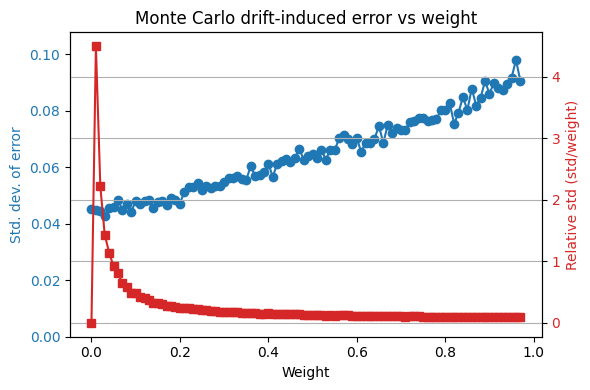

In [56]:
weights = np.linspace(0, 1, 101)  # weight grid
t = (1+2.628e+6/20)                        # drift time
nu_c = (-0.0155 * np.log(1+ 0.00762)) + 0.0244
amp = t**nu_c                    # amplification factor
n_runs = 500                     # Monte Carlo runs

wvals, std_errors = run_sweep(weights, mapping_func, t, amp, n_runs=n_runs)

# Compute relative std safely (avoid divide-by-zero)
rel_std = np.divide(
    std_errors, wvals, 
    out=np.zeros_like(std_errors), 
    where=wvals > 0
)

fig, ax1 = plt.subplots(figsize=(6,4))

# Absolute std
ax1.plot(wvals, std_errors, marker='o', color='tab:blue', label="Absolute std")
ax1.set_xlabel("Weight")
ax1.set_ylabel("Std. dev. of error", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, max(std_errors)*1.1)

# Relative std (second axis)
ax2 = ax1.twinx()
ax2.plot(wvals, rel_std, marker='s', color='tab:red', label="Relative std")
ax2.set_ylabel("Relative std (std/weight)", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Monte Carlo drift-induced error vs weight")
fig.tight_layout()
plt.grid(True)
plt.show()